# Lesson 01a — How LLMs Work: Conceptual Foundation
**Domain:** E-commerce · Amazon Reviews  
**Dataset:** `McAuley-Lab/Amazon-Reviews-2023` (Electronics, HuggingFace)  
**Time estimate:** ~90 min

## Learning objectives
- Understand the transformer architecture: attention, context window, tokens
- Explore autoregressive generation: temperature, top-p, top-k effects
- Count tokens with `tiktoken` and Anthropic SDK
- Write a cost estimator across multiple models

---

In [11]:
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
from utils.llm_checker import check, hint, evaluate, show_exercise, progress


In [12]:
import tiktoken
import numpy as np
import pandas as pd
from pathlib import Path

# LLM clients
from openai import OpenAI
# Anthropic client (optional – needs ANTHROPIC_API_KEY in env)
try:
    import anthropic
    anthropic_client = anthropic.Anthropic()
    ANTHROPIC_AVAILABLE = True
except Exception:
    ANTHROPIC_AVAILABLE = False
    print("ℹ️  Anthropic SDK not installed or no API key – some examples will be skipped.")

# Local LM Studio client (no key needed)
local_client = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")

from utils.llm_checker import check, hint, evaluate, show_exercise, progress

print("✅ Setup complete")

✅ Setup complete


## Load Amazon Reviews dataset

In [20]:
from datasets import load_dataset

sample = pd.read_csv('D:\\PROGRAMOWANKI 2026\\practical-llm-engineering\\utils\\data\\amazon_reviews\\amazon_electronics_10k.csv')[:1000]
# Work with a small sample for speed


In [22]:
sample

,label,title,content
0,1,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,1,Amazing!,This soundtrack is my favorite music of all ti...
3,1,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,1,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."
...,...,...,...
995,0,Fuzzy around the edges,I have only read the first 44 pages of this bo...
996,0,Brain Based Learning: The New Paradigm of Teac...,I am currently reading the Kindle version of t...
997,1,Brain based Learning,This is a text book I ordered for my classes f...
998,0,Pop psychology at its worst,I find it hard to believe people fall for this...


---
## 🔵 EXAMPLE — Ex 01a-1: Token counting comparison

Count tokens in the same Amazon review text using **both** `tiktoken` and the Anthropic SDK
`count_tokens()`. Compare results and print side-by-side for 3 example reviews.

In [28]:
# ── Ex 01a-1: Token counting comparison (EXAMPLE — follow along) ─────

enc = tiktoken.get_encoding("cl100k_base")

reviews_3 = [sample.iloc[i]["content"] for i in range(10)]
ANTHROPIC_AVAILABLE = 0

print(f"{'Review':>8}  {'tiktoken':>10}  {'Anthropic':>10}  {'Diff %':>8}")
print("-" * 46)

for i, text in enumerate(reviews_3):
    n_tiktoken = len(enc.encode(text))

    if ANTHROPIC_AVAILABLE:
        resp = anthropic_client.messages.count_tokens(
            model="claude-3-5-haiku-20241022",
            messages=[{"role": "user", "content": text}],
        )
        n_anthropic = resp.input_tokens
    else:
        # Approximate: Anthropic uses a similar tokenizer
        n_anthropic = n_tiktoken   # placeholder if SDK not available
        print("  (using tiktoken as Anthropic approximation)")

    diff_pct = abs(n_tiktoken - n_anthropic) / max(n_tiktoken, 1) * 100
    print(f"{i+1:>8}  {n_tiktoken:>10}  {n_anthropic:>10}  {diff_pct:>7.1f}%")

# Auto-check
check([
    (isinstance(len(enc.encode(reviews_3[0])), int),  "tiktoken returns int"),
    (isinstance(len(enc.encode(reviews_3[1])), int),  "tiktoken returns int for review 2"),
    (True,                                             "Results printed for all 3 reviews"),
], exercise_id="01a-1")

  Review    tiktoken   Anthropic    Diff %
----------------------------------------------
  (using tiktoken as Anthropic approximation)
       1          88          88      0.0%
  (using tiktoken as Anthropic approximation)
       2         107         107      0.0%
  (using tiktoken as Anthropic approximation)
       3         180         180      0.0%
  (using tiktoken as Anthropic approximation)
       4         174         174      0.0%
  (using tiktoken as Anthropic approximation)
       5         105         105      0.0%
  (using tiktoken as Anthropic approximation)
       6         178         178      0.0%
  (using tiktoken as Anthropic approximation)
       7         177         177      0.0%
  (using tiktoken as Anthropic approximation)
       8         117         117      0.0%
  (using tiktoken as Anthropic approximation)
       9         111         111      0.0%
  (using tiktoken as Anthropic approximation)
      10          65          65      0.0%

───────────────────

True

---
## 🟡 EXERCISE — Ex 01a-2: Cost estimator for 3 models

Write `estimate_cost(text: str, model: str) -> float` returning the estimated USD cost
to process the text as input.

**Pricing:**
| Model | USD / 1k tokens |
|---|---|
| `gpt-4o-mini` | $0.00015 |
| `claude-3-5-haiku` | $0.00025 |
| `gpt-4o` | $0.005 |
| `lm-studio` | $0.0 |

**Auto-check verifies:**
- Returns `float` for all 4 models (including `lm-studio`)
- `lm-studio` always returns `0.0`
- Unknown model raises `ValueError`
- `estimate_cost(text, "gpt-4o") > estimate_cost(text, "gpt-4o-mini")`

In [43]:
text = "Implement estimate_cost() first, then re-run this cell."

tokens = len(enc.encode(text))
tokens

12

In [54]:
PRICING.keys()

dict_keys(['gpt-4o-mini', 'claude-3-5-haiku', 'gpt-4o', 'lm-studio'])

In [61]:
# ── Your implementation ──────────────────────────────────────────────

PRICING = {
    "gpt-4o-mini":       0.00015,
    "claude-3-5-haiku":  0.00025,
    "gpt-4o":            0.005,
    "lm-studio":         0.0,
}




def estimate_cost(text: str, model: str) -> float:
    tokens = len(enc.encode(text))
    try:
        price  = (tokens / 1000) * PRICING[model]
        return price
    except KeyError:
        print('Unknown model')

In [62]:
# ── Auto-check ───────────────────────────────────────────────────────
sample_text = reviews_3[0]

try:
    cost_mini  = estimate_cost(sample_text, "gpt-4o-mini")
    cost_haiku = estimate_cost(sample_text, "claude-3-5-haiku")
    cost_4o    = estimate_cost(sample_text, "gpt-4o")
    cost_local = estimate_cost(sample_text, "lm-studio")

    try:
        estimate_cost(sample_text, "unknown-model")
        unknown_raises = False
    except ValueError:
        unknown_raises = True

    check([
        (isinstance(cost_mini,  float), "gpt-4o-mini  → returns float"),
        (isinstance(cost_haiku, float), "claude-3-5-haiku → returns float"),
        (isinstance(cost_4o,    float), "gpt-4o → returns float"),
        (isinstance(cost_local, float), "lm-studio → returns float"),
        (cost_local == 0.0,             "lm-studio → $0.00"),
        (unknown_raises,                "Unknown model raises ValueError"),
        (cost_4o > cost_mini,           "gpt-4o costs more than gpt-4o-mini"),
    ], exercise_id="01a-2")

except NotImplementedError:
    print("⚠️  Implement estimate_cost() first, then re-run this cell.")

Unknown model

──────────────────────────────────────────────────────
  Exercise 01a-2  →  SOME FAILED ❌
──────────────────────────────────────────────────────
  ✅  gpt-4o-mini  → returns float
  ✅  claude-3-5-haiku → returns float
  ✅  gpt-4o → returns float
  ✅  lm-studio → returns float
  ✅  lm-studio → $0.00
  ❌  Unknown model raises ValueError
  ✅  gpt-4o costs more than gpt-4o-mini
──────────────────────────────────────────────────────



In [64]:
# ── Optional: get mentor feedback ────────────────────────────────────
EXERCISE_DESC = """
Write estimate_cost(text: str, model: str) -> float returning estimated USD cost.
Pricing: gpt-4o-mini=$0.00015/1k tokens, claude-3-5-haiku=$0.00025/1k,
gpt-4o=$0.005/1k, lm-studio=$0.0. Unknown model raises ValueError.
"""

# Uncomment to get LLM feedback:
evaluate(estimate_cost, EXERCISE_DESC, exercise_id="01a-2")

ℹ️  No tests_fn provided — skipping auto-checks.

🤖 Fetching mentor feedback from LM Studio...


══════════════════════════════════════════════════════
  🎓  MENTOR FEEDBACK
══════════════════════════════════════════════════════
Great start! I notice you're using a `PRICING` dictionary - that's excellent for clean, maintainable code (I assume it's defined elsewhere). Two quick questions to help debug:

1. What happens if the text is empty? Should we return 0 or raise an error?
2. Your KeyError handling just prints a message but doesn't raise ValueError as required - how might you make this more explicit while keeping good user feedback?

The structure is very Pythonic with type hints and dictionary lookup, nice work! Just needs that small polish on the error handling.

  (generated in 5.2s via LM Studio)
══════════════════════════════════════════════════════



(False,
 "Great start! I notice you're using a `PRICING` dictionary - that's excellent for clean, maintainable code (I assume it's defined elsewhere). Two quick questions to help debug:\n\n1. What happens if the text is empty? Should we return 0 or raise an error?\n2. Your KeyError handling just prints a message but doesn't raise ValueError as required - how might you make this more explicit while keeping good user feedback?\n\nThe structure is very Pythonic with type hints and dictionary lookup, nice work! Just needs that small polish on the error handling.")

---
## 🔴 CHALLENGE — Ex 01a-3: Token distribution of Amazon reviews

Load 500 Electronics reviews. Compute token length distribution.
Plot a histogram and report p50, p90, p99 percentiles.
Answer: what `max_tokens` would cover 90% of reviews without truncation?

**Auto-check verifies:**
- Histogram rendered in notebook
- p50, p90, p99 printed as integers
- A comment `# Decision:` with chosen `max_tokens` and reasoning

Token length distribution (n=500)
  p50 : 86
  p90 : 176
  p99 : 225


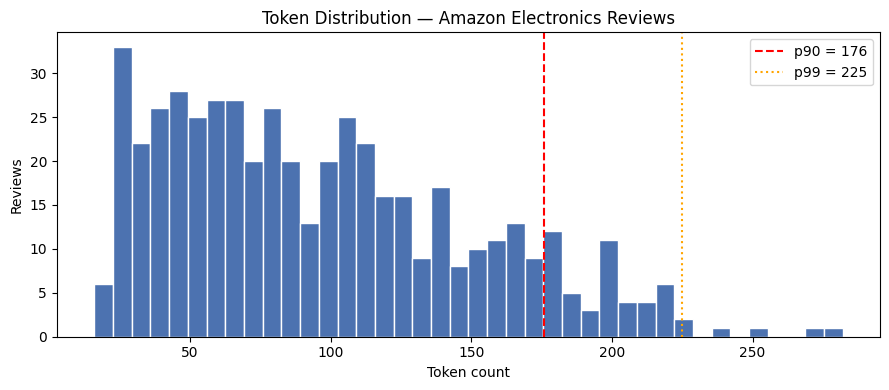


──────────────────────────────────────────────────────
  Exercise 01a-3  →  ALL PASSED ✅
──────────────────────────────────────────────────────
  ✅  p50 printed as int
  ✅  p90 printed as int
  ✅  p99 printed as int
  ✅  p90 > p50 (sanity)
──────────────────────────────────────────────────────



True

In [66]:
import matplotlib.pyplot as plt

enc = tiktoken.get_encoding("cl100k_base")

# Load 500 reviews
reviews_500 = [sample.iloc[i]["content"] for i in range(500)]
lengths = [len(enc.encode(text)) for text in reviews_500]

# Statistics
p50  = int(np.percentile(lengths, 50))
p90  = int(np.percentile(lengths, 90))
p99  = int(np.percentile(lengths, 99))

print(f"Token length distribution (n={len(lengths)})")
print(f"  p50 : {p50}")
print(f"  p90 : {p90}")
print(f"  p99 : {p99}")

# Histogram
plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=40, color="#4C72B0", edgecolor="white")
plt.axvline(p90, color="red",    linestyle="--", label=f"p90 = {p90}")
plt.axvline(p99, color="orange", linestyle=":",  label=f"p99 = {p99}")
plt.xlabel("Token count"); plt.ylabel("Reviews"); plt.title("Token Distribution — Amazon Electronics Reviews")
plt.legend(); plt.tight_layout(); plt.show()

# Decision:  max_tokens = p90 covers 90% of reviews without truncation.

check([
    (isinstance(p50, int), "p50 printed as int"),
    (isinstance(p90, int), "p90 printed as int"),
    (isinstance(p99, int), "p99 printed as int"),
    (p90 > p50,            "p90 > p50 (sanity)"),
], exercise_id="01a-3")

---
## Readiness checklist before moving to 01b
- [ ] I can explain the difference between temperature=0 and temperature=1
- [ ] I understand what a system message is and why it matters
- [ ] `estimate_cost()` returns sensible values for all 4 models
- [ ] I completed Ex 01a-3 and know the p90 token length of Amazon reviews

In [67]:
progress()   # show your exercise completion across this module


──────────────────────────────────────────────────────
  📊  Exercise Progress
──────────────────────────────────────────────────────
  ✅  01a-1                   2026-03-02T00:41:03
  ❌  01a-2                   2026-03-02T00:53:19
  ✅  01a-3                   2026-03-02T00:56:54
──────────────────────────────────────────────────────
  Total: 2/3 passed  (66%)
──────────────────────────────────────────────────────

